Density Ratio Training - Background vs Reference
---

In the 2a and 2b notebooks we will setup the neural networks that train unbiased and low-variance density ratios to be then used for building SBI model, which can be written as:

$$ \frac{L(\mu)}{\prod_e p_\mathrm{ref}(x_e)} = \prod_{x_e\in \{x\}} \frac{1}{\mu \cdot \lambda_\mathrm{sig} + \lambda_\mathrm{bkg}} \left[\mu \cdot \lambda_\mathrm{sig} \cdot \frac{p_\mathrm{sig}(x_e)}{p_\mathrm{ref}(x_e)} + \lambda_\mathrm{bkg} \cdot \frac{p_\mathrm{bkg}(x_e)}{p_\mathrm{ref}(x_e)}\right]$$

which we will then used to build the test statisti in the `3_parameter_fitting.ipynb` notebook. The ratios to estimate using NN are now:

$$ \hat{r}_\mathrm{sig}(x) = \frac{p_\mathrm{sig}(x)}{p_\mathrm{ref}(x)}, \qquad  \hat{r}_\mathrm{bkg}(x) = \frac{p_\mathrm{bkg}(x)}{p_\mathrm{ref}(x)} $$


In this notebook we will estimate $\hat{r}_\mathrm{bkg}(x)$.

In [1]:
import nsbi_common_utils
import pandas as pd
import numpy as np
import mplhep as hep
import matplotlib.pyplot as plt

Insert the path to the downloaded dataset (see README for download link)

In [2]:
BASE_PATH = "./dataframes/"

Load the signal and background datasets

In [3]:
nodes = [0, 5, 10]
signals = {
    f"signal_{n:g}": pd.read_parquet(f"{BASE_PATH}/signal_{n:g}.parquet") for n in nodes
}
signal = signals["signal_10"]
background = pd.read_parquet(f"{BASE_PATH}/background.parquet")

We will use the full high-dimensional feature space to train the density ratios

In [4]:
training_features = ["x1", "x2", "x3", "x4", "x5"]

The numerator and denominator hypothesis refer to the background and reference hypothesis respectively for this notebook. Remember, the objective is to train a model that estimates

$$ \hat{r}_\mathrm{bkg}(x) = \frac{p_\mathrm{bkg}(x)}{p_\mathrm{ref}(x)} $$

We will choose the reference hypothesis to be a combination of signal and backgrounds so there are no phase space regions with $p_\mathrm{ref}(x) \approx 0$ during training.

The choice of reference is one of the difficult and less well-defined parts of the SBI approach -  it has significant impact on numerical stability.

In [5]:
numerator_hypothesis = background.astype('float32').copy()
denominator_hypothesis = pd.concat([background, signals["signal_0"]], ignore_index=True).astype('float32').copy()

Build a combined training dataset consisting of events from numerator and denominator hypothesis. By using `weights_normed` the binary cross-entropy loss function sees both classes represented equally, allowing us to use the likelihood-ratio trick for density ratio estimation. `train_labels` correspond to the truth labels that go into the binary cross-entropy loss function.

In [6]:
numerator_hypothesis["weights"] = numerator_hypothesis['weight']
numerator_hypothesis["weights_normed"] = numerator_hypothesis['weight'] / numerator_hypothesis['weight'].sum()
numerator_hypothesis["train_labels"] = 1.0

denominator_hypothesis["weights"] = denominator_hypothesis['weight']
denominator_hypothesis["weights_normed"] = denominator_hypothesis['weight'] / denominator_hypothesis['weight'].sum()
denominator_hypothesis["train_labels"] = 0.0

In [7]:
N_TRAIN = 2_000_000  # None = use all events

training_dataframe = pd.concat([numerator_hypothesis, denominator_hypothesis], ignore_index=True)
training_dataframe = training_dataframe.sample(frac=1, random_state=43, ignore_index=True)

if N_TRAIN is not None:
    training_dataframe = training_dataframe.head(N_TRAIN).reset_index(drop=True)
    # Re-normalize per-class weights so each class still sums to 1 after subsetting
    for label_val in [0.0, 1.0]:
        mask = training_dataframe["train_labels"] == label_val
        training_dataframe.loc[mask, "weights_normed"] = (
            training_dataframe.loc[mask, "weight"]
            / training_dataframe.loc[mask, "weight"].sum()
        )

### Neural Network Training

In [8]:
ensemble_size = 1

In [9]:
from nsbi_common_utils.training import density_ratio_trainer

trainer = [None for i in range(ensemble_size)]

for ens_index in range(ensemble_size):
    trainer[ens_index] = density_ratio_trainer(
        dataset=training_dataframe,
        weights=training_dataframe["weights_normed"],
        training_labels=training_dataframe["train_labels"],
        features=training_features,
        features_scaling=training_features,
        sample_name=["background", "reference"],
        output_name="",
        path_to_figures="plots_BkgvsRef/",
        path_to_models="models_BkgvsRef/",
    )

### HyperParameters

The default parameters build a wide multi-layer perceptron (MLP) that has been optimized for estimating well-calibrated and unbiased density ratios in most cases.

Exercise: try changing hyperparameters like hidden_layers or neurons or batch_size and see what results you get - both in terms of diagnostics and final parameter fits.

In [10]:
for ens_index in range(ensemble_size):
    trainer[ens_index].train(
        hidden_layers=3,
        neurons=1024,
        number_of_epochs=30,
        batch_size=1024,
        learning_rate=1e-3,
        scalerType="MinMax",
        ensemble_index=ens_index,
        verbose=1,
        holdout_split=0.25, # validation
        validation_split=0.2,
        callback_patience=10,
        num_workers=4,
        load_trained_models=True,
        calibration=False,
        type_of_calibration = "histogram",
        recalibrate_output=True,
        num_bins_cal = 50
    )

2026-05-20 11:52:40 | INFO | Training Logs | Reading saved models from models_BkgvsRef/
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/.pixi/envs/nsbi-env/lib/python3.12/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:123: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'CoreMLExecutionProvider, AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/.pixi/envs/nsbi-env/lib/python3.12/site-packages/onnxruntime/capi/onnxruntime_inference_collection.py:123: UserWarning: Specified provider 'CUDAExecutionProvider' is not in available provider names.Available providers: 'CoreMLExecutionProvider, AzureExecutionProvider, CPUExecutionProvider'
  warnings.warn(


Diagnostic Checks
===

While traditionally, a NN observable is judged on the basis of its accuracy - for NSBI we are interested in the quality of the density ratios more than the discrimination power. The latter comes from the perfect modelling of the multi-dimensional likelihood ratios.

To ensure correct modelling, we run two main checks on the training:

- **Calibration closure test**

  The NNs are trained using the binary cross-entropy loss, which under ideal conditions leads to the NN converging to the score function:

  $$\hat{s}_\text{pred} = \frac{p_\text{s}(x)}{p_\text{ref}(x)+p_\text{s}(x)}$$

  that can be converted into the probability ratio we desire (likelihood ratio trick):

  $$\frac{p_\text{s}(x)}{p_\text{ref}(x)} = \frac{\hat{s}_\text{pred}(x)}{1-\hat{s}_\text{pred}(x)}$$

  For the NNs to be well-calibrated, we use the Monte Carlo samples to verify the equality:


  $$\left[\frac{p_s(x)}{p_s(x)+p_{ref}(x)}\right]_\text{NN} \sim \left[\frac{\mathcal{N}_s^{I(x|\hat{s}_\text{pred})}}{\mathcal{N}_s^{I(x|\hat{s}_\text{pred})}+\mathcal{N}_\text{ref}^{I(x|\hat{s}_\text{pred})}}\right]_\text{MC}$$

  where we bin the events from $p_c$ and $p_\text{ref}$ MC samples, denoted by $\mathcal{N}_s^{I(x|\hat{s}_\text{pred})}$ and $\mathcal{N}_\text{ref}^{I(x|\hat{s}_\text{pred})}$ respectively where $I(x|\hat{s}_\text{pred})$ returns the index of the $\hat{s}_\text{pred}$ bin in which an event $x$ falls.
 


In [11]:
ens_index_to_plot = 0

/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:66: RuntimeWarning: invalid value encountered in divide
  hist_ratio = hist_num / (hist_den + hist_num)
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:68: RuntimeWarning: divide by zero encountered in divide
  hist_ratio**2 * np.abs(hist_den / hist_num) *
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:68: RuntimeWarning: invalid value encountered in divide
  hist_ratio**2 * np.abs(hist_den / hist_num) *
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:68: RuntimeWarning: invalid value encountered in multiply
  hist_ratio**2 * np.abs(hist_den / hist_num) *
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:69: RuntimeWarning: invalid value encountered in divide
  np.sqrt((hist_num_err / (hist_num)**2) + (hist_den_err / (hist_den)**2))
/Users/jaysandesara/Deskt

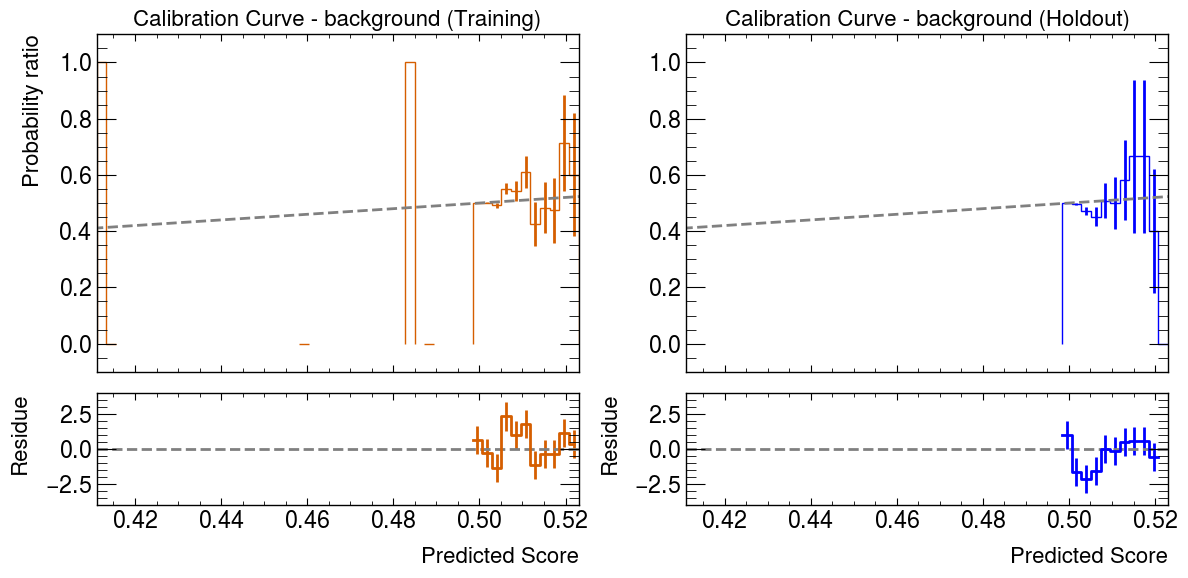

<Figure size 800x600 with 0 Axes>

In [15]:
trainer[ens_index_to_plot].make_calib_plots(observable='score', nbins=50, ensemble_index=0)

## Density ratio reweighting closure tests
  
Despite having a well-calibrated output and thus a robust probabilistic interpretation, the trained density ratios might not capture the full multi-dimensional event information $x$. 

The next diagnostic involves verifying the following equality using 1D projections of $x$:

$$\frac{p_s(x)}{p_{ref}(x)} \times p_{ref}(x) \sim p_s(x)$$

We can do this one-by-one for all the observables used to model the density ratios, and also possibly the observables not used directly in the training but can still be well-estimated due to the NN learning the right physics.

/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:296: RuntimeWarning: divide by zero encountered in divide
  rat_L = L['hist_den']/L['hist_num']
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:297: RuntimeWarning: invalid value encountered in divide
  yerr_L = np.abs(rat_L*np.sqrt((np.sqrt(L['hist_den_err'])/L['hist_den'])**2 + (np.sqrt(L['hist_num_err'])/L['hist_num'])**2))


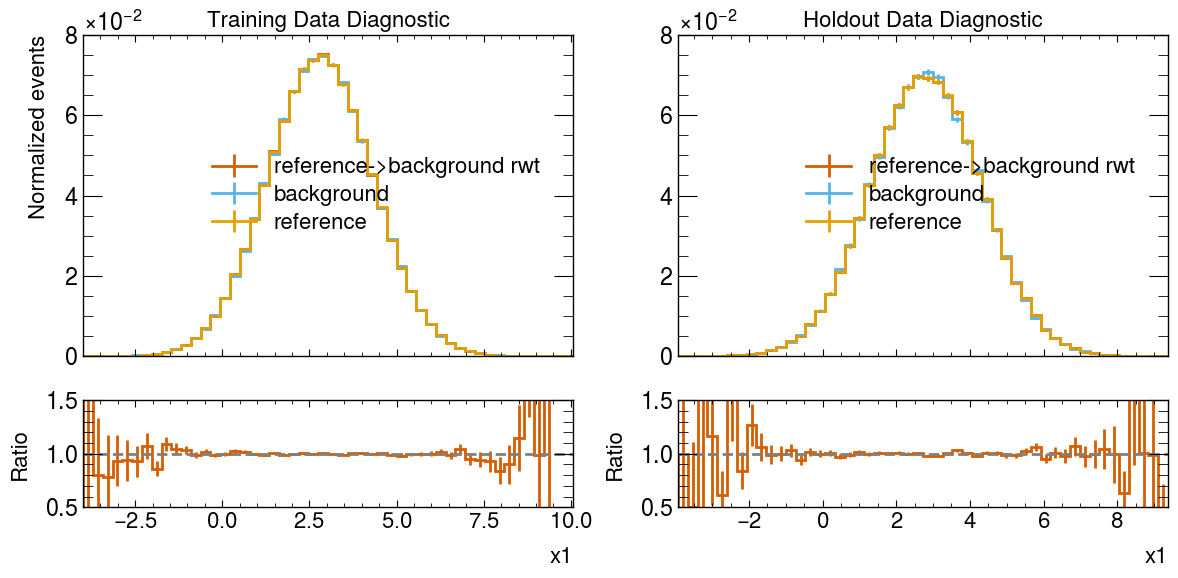

/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:296: RuntimeWarning: divide by zero encountered in divide
  rat_L = L['hist_den']/L['hist_num']
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:297: RuntimeWarning: invalid value encountered in divide
  yerr_L = np.abs(rat_L*np.sqrt((np.sqrt(L['hist_den_err'])/L['hist_den'])**2 + (np.sqrt(L['hist_num_err'])/L['hist_num'])**2))
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:319: RuntimeWarning: divide by zero encountered in divide
  rat_R = R['hist_den']/R['hist_num']
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:319: RuntimeWarning: invalid value encountered in divide
  rat_R = R['hist_den']/R['hist_num']
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:320: RuntimeWarning: invalid value encountered in divide
  yerr_R = np.abs(rat_R*np.sqrt((np.sqrt(R['hi

<Figure size 800x600 with 0 Axes>

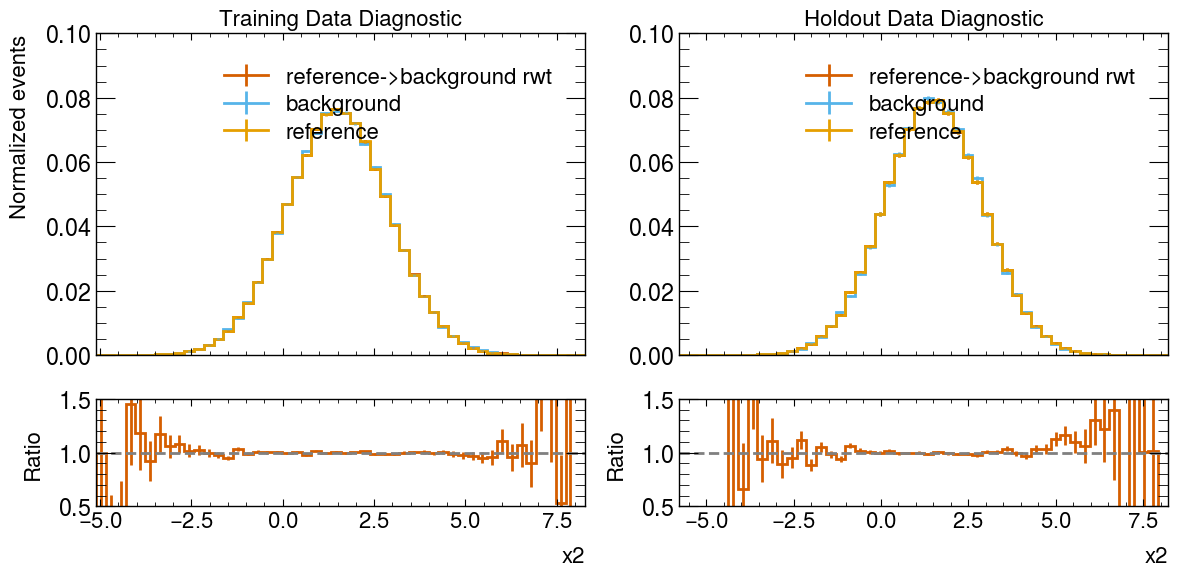

/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:297: RuntimeWarning: invalid value encountered in divide
  yerr_L = np.abs(rat_L*np.sqrt((np.sqrt(L['hist_den_err'])/L['hist_den'])**2 + (np.sqrt(L['hist_num_err'])/L['hist_num'])**2))
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:319: RuntimeWarning: divide by zero encountered in divide
  rat_R = R['hist_den']/R['hist_num']
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:319: RuntimeWarning: invalid value encountered in divide
  rat_R = R['hist_den']/R['hist_num']
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:320: RuntimeWarning: invalid value encountered in divide
  yerr_R = np.abs(rat_R*np.sqrt((np.sqrt(R['hist_den_err'])/R['hist_den'])**2 + (np.sqrt(R['hist_num_err'])/R['hist_num'])**2))


<Figure size 800x600 with 0 Axes>

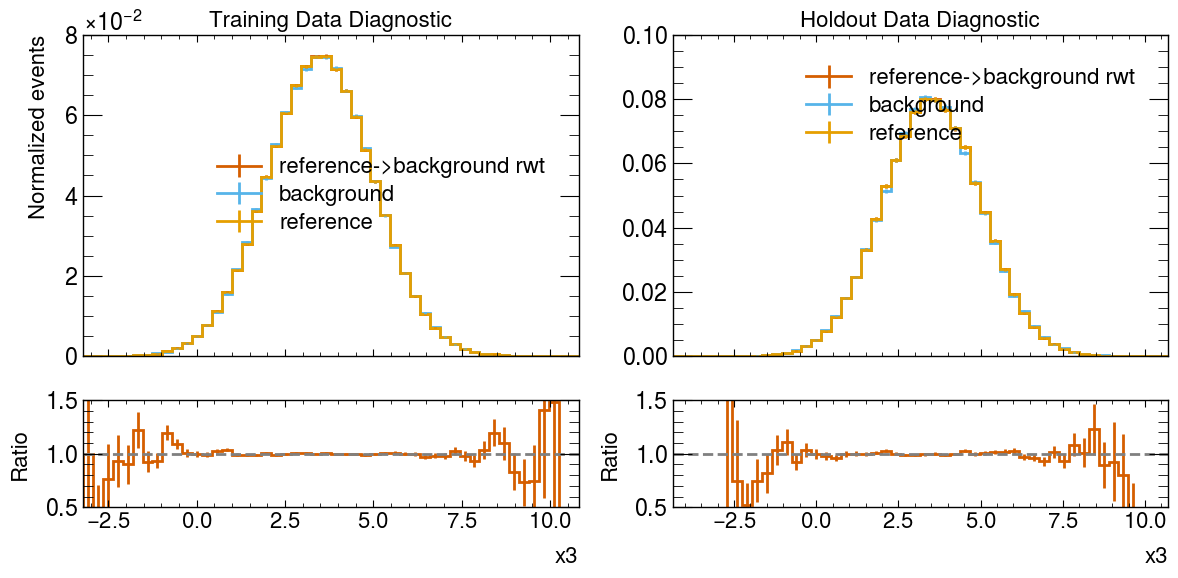

/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:297: RuntimeWarning: invalid value encountered in divide
  yerr_L = np.abs(rat_L*np.sqrt((np.sqrt(L['hist_den_err'])/L['hist_den'])**2 + (np.sqrt(L['hist_num_err'])/L['hist_num'])**2))
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:319: RuntimeWarning: divide by zero encountered in divide
  rat_R = R['hist_den']/R['hist_num']
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:319: RuntimeWarning: invalid value encountered in divide
  rat_R = R['hist_den']/R['hist_num']
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:320: RuntimeWarning: invalid value encountered in divide
  yerr_R = np.abs(rat_R*np.sqrt((np.sqrt(R['hist_den_err'])/R['hist_den'])**2 + (np.sqrt(R['hist_num_err'])/R['hist_num'])**2))


<Figure size 800x600 with 0 Axes>

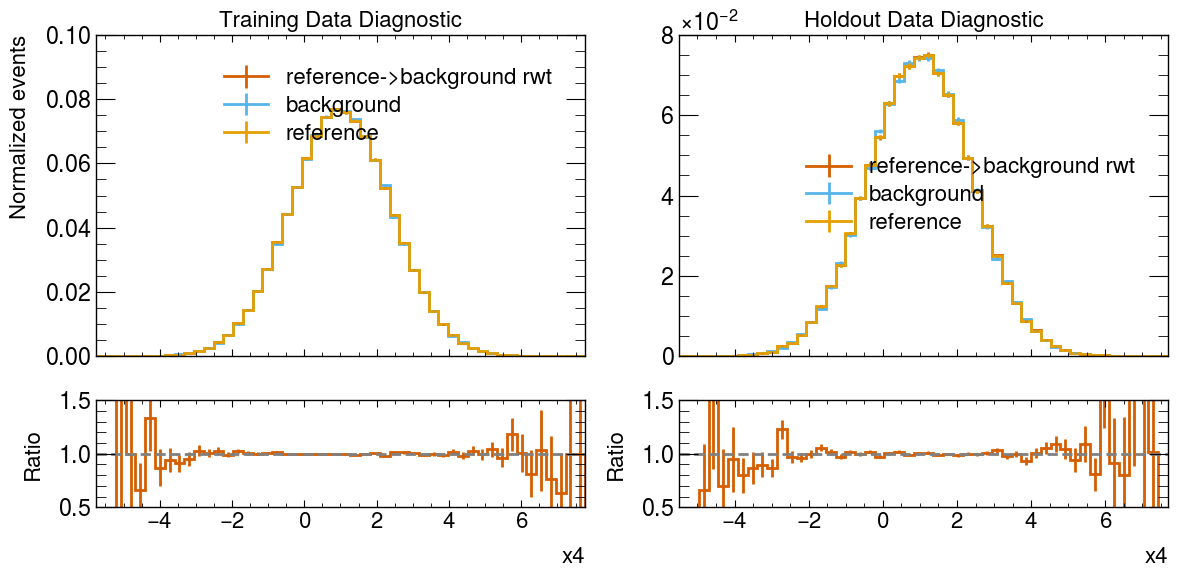

/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:296: RuntimeWarning: invalid value encountered in divide
  rat_L = L['hist_den']/L['hist_num']
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:297: RuntimeWarning: invalid value encountered in divide
  yerr_L = np.abs(rat_L*np.sqrt((np.sqrt(L['hist_den_err'])/L['hist_den'])**2 + (np.sqrt(L['hist_num_err'])/L['hist_num'])**2))
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:319: RuntimeWarning: divide by zero encountered in divide
  rat_R = R['hist_den']/R['hist_num']
/Users/jaysandesara/Desktop/NSBI-workflow-tutorial/src/nsbi_common_utils/plotting.py:320: RuntimeWarning: invalid value encountered in divide
  yerr_R = np.abs(rat_R*np.sqrt((np.sqrt(R['hist_den_err'])/R['hist_den'])**2 + (np.sqrt(R['hist_num_err'])/R['hist_num'])**2))


<Figure size 800x600 with 0 Axes>

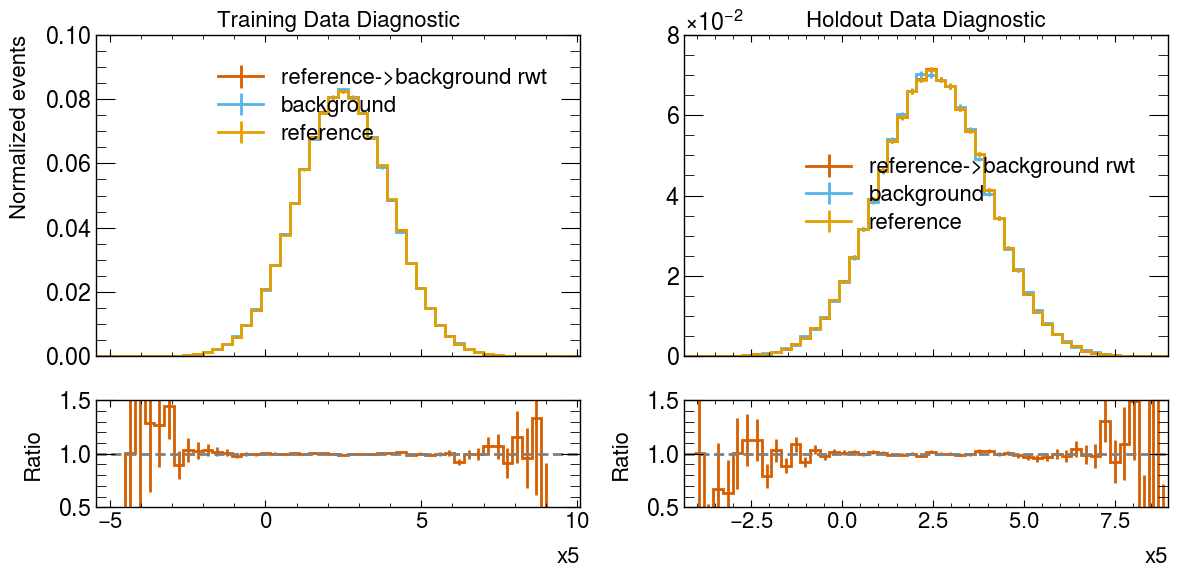

<Figure size 800x600 with 0 Axes>

In [13]:
trainer[ens_index_to_plot].make_reweighted_plots(training_features, "linear", 50)